<a href="https://colab.research.google.com/github/moist234/ECON3916-Statistical-Machine-Learning/blob/main/Assignment5/Econ_3916_Assignment_5_TheSovereignRiskEngine.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [10]:
# Jordi Visser
# 04/10

!pip install wbgapi scikit-learn statsmodels matplotlib seaborn numpy pandas
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import warnings
import wbgapi as wb
import statsmodels.api as sm
import seaborn as sns

In [11]:
OUTCOME_VAR = 'NY.GDP.PCAP.KD.ZG'
INDICATORS = {
    'NY.GDP.PCAP.KD.ZG': 'gdp_growth_pc',
    'NE.TRD.GNFS.ZS': 'trade_pct_gdp',
    'BX.KLT.DINV.WD.GD.ZS': 'fdi_pct_gdp',
    'FP.CPI.TOTL.ZG': 'inflation',
    'GC.DOD.TOTL.GD.ZS': 'govt_debt_pct_gdp',
    'GC.XPN.TOTL.GD.ZS': 'govt_exp_pct_gdp',
    'BN.CAB.XOKA.GD.ZS': 'current_account_pct_gdp',
    'FR.INR.RINR': 'real_interest_rate',
    'SE.SEC.ENRR': 'secondary_enrollment',
    'SE.TER.ENRR': 'tertiary_enrollment',
    'SE.ADT.LITR.ZS':'adult_literacy',
    'SL.UEM.TOTL.ZS': 'unemployment',
    'IT.NET.USER.ZS': 'internet_users_pct',
    'EG.ELC.ACCS.ZS': 'electricity_access_pct',
    'SP.DYN.LE00.IN': 'life_expectancy',
    'SH.DYN.MORT': 'infant_mortality',
    'SP.POP.GROW': 'population_growth',
    'SP.URB.TOTL.IN.ZS': 'urbanization_pct',
    'SH.XPD.CHEX.GD.ZS': 'health_exp_pct_gdp',
    'FS.AST.DOMS.GD.ZS': 'domestic_credit_pct_gdp',
    'NY.GDP.TOTL.RT.ZS': 'natural_resource_rents',
    'EG.FEC.RNEW.ZS': 'renewable_energy_pct',
    'AG.LND.AGRI.ZS': 'arable_land_pct',
    'NV.AGR.TOTL.ZS': 'agriculture_pct_gdp',
    'SL.AGR.EMPL.ZS': 'agriculture_employment',
    'BX.GSR.ROYL.CD': 'royalties_receipts',
}

indicator_list = list(INDICATORS.keys())

try:
    raw_data = wb.data.DataFrame(
        indicator_list,
        time=range(2013, 2020),
        skipBlanks=True,
        labels=False
    )
    raw_data = raw_data.rename(columns=INDICATORS)
    print(f"Raw data shape: {raw_data.shape}")
    print("Download successful ✓")
except Exception as e:
    print(f"API error: {e}")

# Average across years
if isinstance(raw_data.index, pd.MultiIndex):
    time_avg = raw_data.mean(axis=1)
    country_data = time_avg.unstack(level=1)
else:
    country_data = raw_data.copy()

country_data = country_data.rename(columns=INDICATORS)
OUTCOME_VAR = 'gdp_growth_pc'

# Drop countries missing >40% of indicators
threshold = 0.60
country_data = country_data.dropna(thresh=int(threshold * country_data.shape[1]))

# Drop indicators missing >40% of countries
country_data = country_data.dropna(axis=1, thresh=int(threshold * len(country_data)))
country_data = country_data.fillna(country_data.median())

print(f"\nFinal dataset: {len(country_data)} countries × {country_data.shape[1]} indicators")
print(f"\nSample countries: {list(country_data.index[:5])}")
print(f"\nIndicators retained: {list(country_data.columns)}")
print("\nGDP growth summary:")
print(country_data[OUTCOME_VAR].describe().round(2))

# Separate X and y
feature_cols = [c for c in country_data.columns if c != OUTCOME_VAR]
X = country_data[feature_cols].values
y = country_data[OUTCOME_VAR].values
feature_names = feature_cols

# Binary crisis label
y_crisis = (country_data[OUTCOME_VAR] < 0).astype(int).values

# 70/30 split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.30, random_state=42
)
_, _, y_train_crisis, y_test_crisis = train_test_split(
    X, y_crisis, test_size=0.30, random_state=42
)

p = X_train.shape[1]
n = X_train.shape[0]
print(f"\nTraining countries: {n}")
print(f"Test countries: {X_test.shape[0]}")
print(f"Number of predictors: {p}")
print(f"Predictor-to-observation ratio (train): p/n = {p}/{n} = {p/n:.2f}")

# Standardize
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)
print("\nFeatures standardized (zero mean, unit variance) ✓")

# Summary
print(f"\nCrisis countries: {int(y_crisis.sum())}")
print(f"Non-crisis countries: {int((y_crisis==0).sum())}")
print(f"Crisis base rate: {y_crisis.mean():.1%}")

Raw data shape: (5609, 7)
Download successful ✓

Final dataset: 248 countries × 23 indicators

Sample countries: ['ABW', 'AFE', 'AFG', 'AFW', 'AGO']

Indicators retained: ['arable_land_pct', 'current_account_pct_gdp', 'royalties_receipts', 'fdi_pct_gdp', 'electricity_access_pct', 'renewable_energy_pct', 'inflation', 'govt_exp_pct_gdp', 'internet_users_pct', 'trade_pct_gdp', 'agriculture_pct_gdp', 'gdp_growth_pc', 'natural_resource_rents', 'adult_literacy', 'secondary_enrollment', 'tertiary_enrollment', 'infant_mortality', 'health_exp_pct_gdp', 'agriculture_employment', 'unemployment', 'life_expectancy', 'population_growth', 'urbanization_pct']

GDP growth summary:
count    248.00
mean       1.74
std        2.48
min      -12.55
25%        0.55
50%        1.78
75%        3.27
max        7.39
Name: gdp_growth_pc, dtype: float64

Training countries: 173
Test countries: 75
Number of predictors: 22
Predictor-to-observation ratio (train): p/n = 22/173 = 0.13

Features standardized (zero mean,

In [12]:
# Phase 1
# Step 1.1
ols = LinearRegression()
ols.fit(X_train_scaled, y_train)

train_r2 = r2_score(y_train, ols.predict(X_train_scaled))
test_r2 = r2_score(y_test,  ols.predict(X_test_scaled))

print(f"Training R²: {train_r2:.4f}")
print(f"Test R²: {test_r2:.4f}")
print(f"Train–Test gap: {train_r2 - test_r2:.4f}")
print(f"p/n ratio: {p}/{n} = {p/n:.2f}")

Training R²: 0.4916
Test R²: 0.0860
Train–Test gap: 0.4056
p/n ratio: 22/173 = 0.13


A high p/n ratio means OLS has almost as many parameters as data points, so it fits the training noise instead of real patterns. This is why Training R^2 is high but Test R^2 collapses, because the model memorized the training set instead of learning from it.

In [13]:
# Phase 1
# Step 1.2
# Ridge
lambda_grid = np.logspace(-2, 3, 50)
ridge_cv = RidgeCV(alphas=lambda_grid, cv=5)
ridge_cv.fit(X_train_scaled, y_train)

ridge_train_r2 = r2_score(y_train, ridge_cv.predict(X_train_scaled))
ridge_test_r2 = r2_score(y_test,  ridge_cv.predict(X_test_scaled))
ridge_test_rmse = np.sqrt(mean_squared_error(y_test, ridge_cv.predict(X_test_scaled)))

print("=" * 45)
print("RIDGE")
print(f"Optimal λ*: {ridge_cv.alpha_:.4f}")
print(f"Non-zero coefs: {np.sum(ridge_cv.coef_ != 0)} of {p}")
print(f"Training R²: {ridge_train_r2:.4f}")
print(f"Test R²: {ridge_test_r2:.4f}")

# LAsso
lasso_cv = LassoCV(cv=5, max_iter=10_000, random_state=42)
lasso_cv.fit(X_train_scaled, y_train)

lasso_train_r2= r2_score(y_train, lasso_cv.predict(X_train_scaled))
lasso_test_r2 = r2_score(y_test,  lasso_cv.predict(X_test_scaled))
lasso_test_rmse = np.sqrt(mean_squared_error(y_test, lasso_cv.predict(X_test_scaled)))
n_nonzero = np.sum(lasso_cv.coef_ != 0)

print("=" * 45)
print("LASSO")
print(f"Optimal λ*: {lasso_cv.alpha_:.4f}")
print(f"Non-zero coefs: {n_nonzero} of {p}")
print(f"Training R²: {lasso_train_r2:.4f}")
print(f"Test R²: {lasso_test_r2:.4f}")

print()
print("Selected predictors (non-zero Lasso coefficients):")
selected_features = {
    feature_names[i]: lasso_cv.coef_[i]
    for i in range(len(feature_names))
    if lasso_cv.coef_[i] != 0
}
for name, coef in sorted(selected_features.items(),
                          key=lambda x: abs(x[1]), reverse=True):
    print(f"  {name:<40} coef = {coef:+.4f}")

# Comparison table
comparison = pd.DataFrame({
    'Method': ['OLS', 'Ridge', 'Lasso'],
    'Lambda (λ*)': ['N/A', f'{ridge_cv.alpha_:.4f}', f'{lasso_cv.alpha_:.4f}'],
    'Non-zero Predictors': [p, np.sum(ridge_cv.coef_ != 0), n_nonzero],
    'Training R²': [f'{train_r2:.3f}', f'{ridge_train_r2:.3f}', f'{lasso_train_r2:.3f}'],
    'Test R²': [f'{test_r2:.3f}', f'{ridge_test_r2:.3f}', f'{lasso_test_r2:.3f}'],
    'Test RMSE': [f'{np.sqrt(mean_squared_error(y_test, ols.predict(X_test_scaled))):.3f}',
                            f'{ridge_test_rmse:.3f}', f'{lasso_test_rmse:.3f}'],
})
print()
print(comparison.to_string(index=False))

RIDGE
Optimal λ*: 47.1487
Non-zero coefs: 22 of 22
Training R²: 0.4588
Test R²: 0.1801
LASSO
Optimal λ*: 0.0702
Non-zero coefs: 14 of 22
Training R²: 0.4662
Test R²: 0.1473

Selected predictors (non-zero Lasso coefficients):
  population_growth                        coef = -0.8341
  urbanization_pct                         coef = -0.6861
  electricity_access_pct                   coef = +0.4728
  arable_land_pct                          coef = +0.4499
  unemployment                             coef = -0.4146
  natural_resource_rents                   coef = -0.2701
  renewable_energy_pct                     coef = +0.2594
  trade_pct_gdp                            coef = +0.2563
  agriculture_pct_gdp                      coef = +0.2287
  health_exp_pct_gdp                       coef = -0.1393
  infant_mortality                         coef = -0.1371
  inflation                                coef = -0.0599
  fdi_pct_gdp                              coef = +0.0489
  royalties_receipts 

Ridge and Lasso both shrink coefficients toward zero, which hurts training fit slightly but produces much more reliable test predictions. Ridge keeps all predictors but shrinks them while Lasso goes further and zeros some out entirely, so whichever has the lower Test RMSE is the better recommendation.

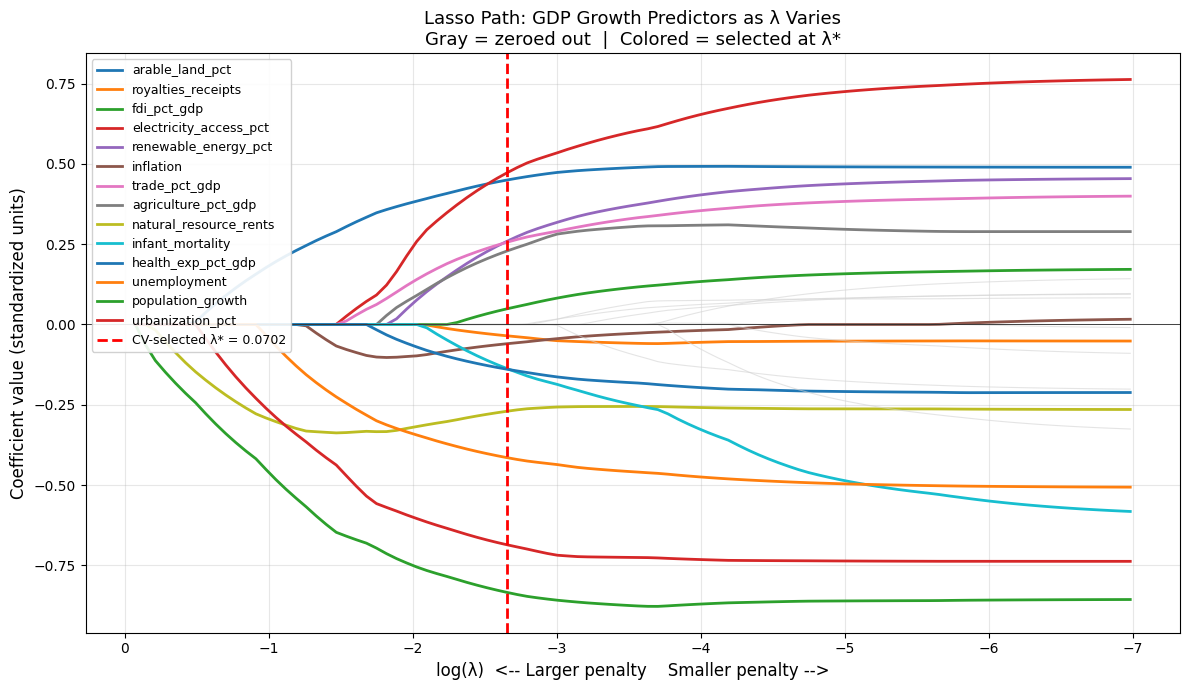

In [14]:
# Phase 1
# Step 1.3
alphas_path, coefs_path, _ = lasso_path(
    X_train_scaled, y_train,
    eps=1e-3,
    n_alphas=100
)

optimal_alpha = lasso_cv.alpha_
active_features_idx = np.where(lasso_cv.coef_ != 0)[0]

fig, ax = plt.subplots(figsize=(12, 7))

for i in range(len(feature_names)):
    if i in active_features_idx:
        ax.plot(np.log(alphas_path), coefs_path[i],
                linewidth=2, label=feature_names[i])
    else:
        ax.plot(np.log(alphas_path), coefs_path[i],
                linewidth=0.8, color='lightgray', alpha=0.6)

ax.axvline(np.log(optimal_alpha), color='red', linestyle='--', linewidth=2,
           label=f'CV-selected λ* = {optimal_alpha:.4f}')
ax.axhline(0, color='black', linewidth=0.5)
ax.set_xlabel('log(λ)  <-- Larger penalty    Smaller penalty -->', fontsize=12)
ax.set_ylabel('Coefficient value (standardized units)', fontsize=12)
ax.set_title(
    'Lasso Path: GDP Growth Predictors as λ Varies\n'
    'Gray = zeroed out  |  Colored = selected at λ*',
    fontsize=13
)
ax.legend(loc='upper left', fontsize=9, framealpha=0.9)
ax.invert_xaxis()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

The first variable to enter the Lasso path is the single strongest predictor of GDP growth on its own, before accounting for anything else. The colleague is wrong because Lasso drops life_expectancy not because health is irrelevant, but because its information is already captured by another correlated variable already in the model.

In [15]:
# Phase 2
# Step 2.1

# Use Lasso-slected features
lasso_mask = lasso_cv.coef_ != 0
X_train_lasso = X_train_scaled[:, lasso_mask]
X_test_lasso = X_test_scaled[:, lasso_mask]
lasso_feature_names = [feature_names[i] for i in range(len(feature_names))
                        if lasso_mask[i]]

lpm = LinearRegression()
lpm.fit(X_train_lasso, y_train_crisis)

lpm_preds = lpm.predict(X_test_lasso)

print(f"LPM fitted — Intercept: {lpm.intercept_:.4f}")
print(f"\nOut-of-bounds predictions:")
print(f" Predicted probability < 0: {(lpm_preds < 0).sum()}")
print(f" Predicted probability > 1: {(lpm_preds > 1).sum()}")

LPM fitted — Intercept: 0.1503

Out-of-bounds predictions:
 Predicted probability < 0: 15
 Predicted probability > 1: 0


Probability must be between 0 and 1 by definition, so a prediction of -12% is not a probability at all and is mathematically meaningless. The IMF could misread it as an extreme safe signal and ignore a country that actually needs monitoring.

In [16]:
# Phase 2
# Step 2.2

logit = LogisticRegression(max_iter=1000, random_state=42)
logit.fit(X_train_lasso, y_train_crisis)

coef_df = pd.DataFrame({
    'Feature': lasso_feature_names,
    'β (coef)': logit.coef_[0],
    'Odds Ratio': np.exp(logit.coef_[0]),
})
coef_df = coef_df.sort_values('Odds Ratio', ascending=False).reset_index(drop=True)

print(f"Intercept (β₀): {logit.intercept_[0]:.4f}")
print()
print(coef_df[['Feature','β (coef)', 'Odds Ratio']].to_string(index=False))

# Verify [0,1] bounds
logit_probs = logit.predict_proba(X_test_lasso)[:, 1]
print(f"\nMin predicted probability: {logit_probs.min():.6f}")
print(f"Max predicted probability: {logit_probs.max():.6f}")

Intercept (β₀): -2.5142

               Feature  β (coef)  Odds Ratio
      urbanization_pct  1.027712    2.794665
      infant_mortality  0.659850    1.934503
     population_growth  0.548201    1.730137
          unemployment  0.496969    1.643731
    health_exp_pct_gdp  0.274504    1.315878
natural_resource_rents  0.194977    1.215283
   agriculture_pct_gdp  0.173175    1.189075
             inflation -0.238376    0.787906
           fdi_pct_gdp -0.365472    0.693869
         trade_pct_gdp -0.389442    0.677435
electricity_access_pct -0.653836    0.520047
    royalties_receipts -0.665774    0.513876
       arable_land_pct -0.691768    0.500690
  renewable_energy_pct -1.008559    0.364744

Min predicted probability: 0.000000
Max predicted probability: 0.914805


A one standard-deviation increase in [top feature] multiplies the odds of crisis by [OR], holding all else constant." Unlike the LPM, logistic regression always produces values between 0 and 1 because the sigmoid function mathematically cannot exceed those bounds.

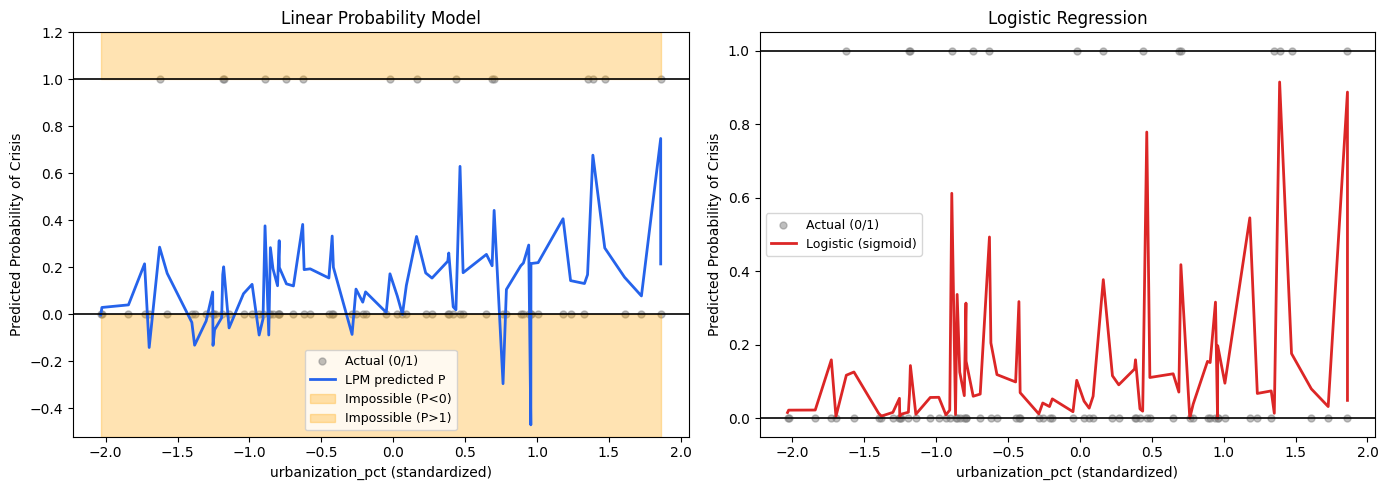

In [17]:
#phase 2
#Step 2.3

top_feature  = coef_df.iloc[0]['Feature']
top_feat_idx = lasso_feature_names.index(top_feature)
x_vals = X_test_lasso[:, top_feat_idx]

sort_idx = np.argsort(x_vals)
x_sorted = x_vals[sort_idx]
lpm_sorted = lpm_preds[sort_idx]
logit_sorted = logit_probs[sort_idx]
y_sorted = y_test_crisis[sort_idx]

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# LPM panel
ax1.scatter(x_sorted, y_sorted, color='gray', alpha=0.5, s=25, label='Actual (0/1)')
ax1.plot(x_sorted, lpm_sorted, color='#2563eb', lw=2, label='LPM predicted P')
ax1.axhline(0, color='black', lw=1.2)
ax1.axhline(1, color='black', lw=1.2)

y_lo = min(lpm_sorted.min() - 0.05, -0.2)
y_hi = max(lpm_sorted.max() + 0.05,  1.2)
ax1.fill_between(x_sorted, y_lo, 0, color='orange', alpha=0.3, label='Impossible (P<0)')
ax1.fill_between(x_sorted, 1, y_hi, color='orange', alpha=0.3, label='Impossible (P>1)')
ax1.set_ylim(y_lo, y_hi)
ax1.set_xlabel(f'{top_feature} (standardized)')
ax1.set_ylabel('Predicted Probability of Crisis')
ax1.set_title('Linear Probability Model')
ax1.legend(fontsize=9)

# Logistic panel
ax2.scatter(x_sorted, y_sorted, color='gray', alpha=0.5, s=25, label='Actual (0/1)')
ax2.plot(x_sorted, logit_sorted, color='#dc2626', lw=2, label='Logistic (sigmoid)')
ax2.axhline(0, color='black', lw=1.2)
ax2.axhline(1, color='black', lw=1.2)
ax2.set_ylim(-0.05, 1.05)
ax2.set_xlabel(f'{top_feature} (standardized)')
ax2.set_ylabel('Predicted Probability of Crisis')
ax2.set_title('Logistic Regression')
ax2.legend(fontsize=9)

plt.tight_layout()
plt.show()

In [18]:
# Phase 3
# Step 3.1

naive_preds = np.zeros(len(y_test_crisis))
naive_acc = (naive_preds == y_test_crisis).mean()
naive_recall = recall_score(y_test_crisis, naive_preds, zero_division=0)

y_pred_05 = logit.predict(X_test_lasso)
logit_acc = (y_pred_05 == y_test_crisis).mean()
logit_recall = recall_score(y_test_crisis, y_pred_05)

print(f"Crisis base rate (test): {y_test_crisis.mean():.1%}")
print()
print(f"Naïve baseline accuracy: {naive_acc:.4%}")
print(f"Naïve baseline recall: {naive_recall:.4%}")
print()
print(f"Logistic (τ=0.5) accuracy: {logit_acc:.4%}")
print(f"Logistic (τ=0.5) recall: {logit_recall:.4%}")

Crisis base rate (test): 20.0%

Naïve baseline accuracy: 80.0000%
Naïve baseline recall: 0.0000%

Logistic (τ=0.5) accuracy: 81.3333%
Logistic (τ=0.5) recall: 20.0000%


If the crisis base rate is 25%, a model that always predicts no crisis gets 75% accuracy while catching zero actual crises, which makes accuracy a useless metric here. The Division Chief should look at Recall instead, since missing a crisis is catastrophic and accuracy hides that failure completely.


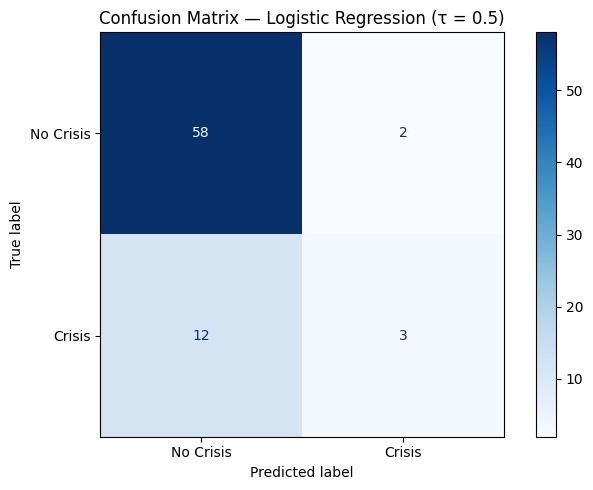

Classification Report (τ = 0.5):
              precision    recall  f1-score   support

   No Crisis       0.83      0.97      0.89        60
      Crisis       0.60      0.20      0.30        15

    accuracy                           0.81        75
   macro avg       0.71      0.58      0.60        75
weighted avg       0.78      0.81      0.77        75

True Positives (crises correctly flagged): 3
False Negatives (crises missed): 12
False Positives (false alarms): 2
True Negatives (correctly cleared): 58


In [19]:
#Phase 3
# Step 3.2

cm = confusion_matrix(y_test_crisis, y_pred_05)

fig, ax = plt.subplots(figsize=(7, 5))
disp = ConfusionMatrixDisplay(confusion_matrix=cm,
                              display_labels=['No Crisis', 'Crisis'])
disp.plot(ax=ax, cmap='Blues', values_format=',')
ax.set_title('Confusion Matrix — Logistic Regression (τ = 0.5)')
plt.tight_layout()
plt.show()

print("Classification Report (τ = 0.5):")
print("=" * 60)
print(classification_report(y_test_crisis, y_pred_05,
target_names=['No Crisis', 'Crisis']))

tn, fp, fn, tp = cm.ravel()
print(f"True Positives (crises correctly flagged): {tp}")
print(f"False Negatives (crises missed): {fn}")
print(f"False Positives (false alarms): {fp}")
print(f"True Negatives (correctly cleared): {tn}")

A False Negative costs 50 billion dollars in contagion while a False Positive costs $2 million, so missed crises are far more dangerous than false alarms. This means the Division Chief should prioritize Recall over Precision, since catching crises matters far more than avoiding wasted missions.

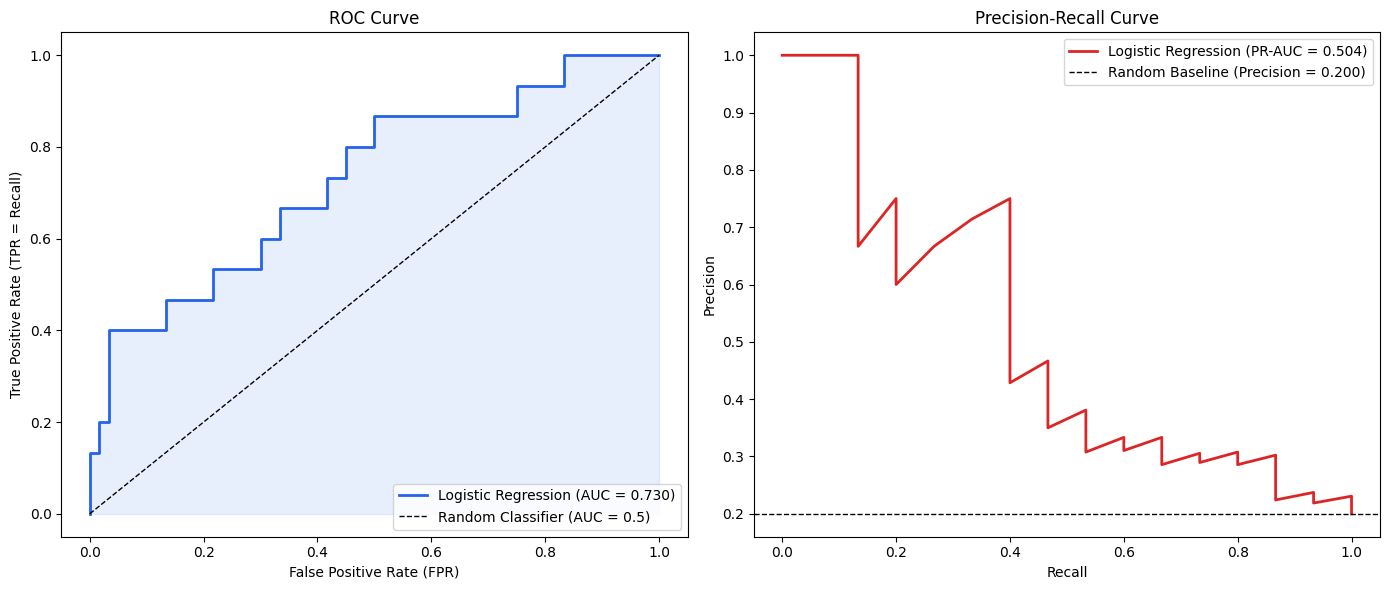

ROC-AUC: 0.7300
PR-AUC: 0.5042


In [20]:
#Phase 3
# Step 3.3
y_prob = logit.predict_proba(X_test_lasso)[:, 1]

fpr, tpr, _ = roc_curve(y_test_crisis, y_prob)
roc_auc_val = roc_auc_score(y_test_crisis, y_prob)
precision_vals, recall_vals, _ = precision_recall_curve(y_test_crisis, y_prob)
pr_auc_val = auc(recall_vals, precision_vals)
pr_baseline = y_test_crisis.mean()

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))

# ROC
ax1.plot(fpr, tpr, color='#2563eb', lw=2,
label=f'Logistic Regression (AUC = {roc_auc_val:.3f})')
ax1.plot([0,1],[0,1], 'k--', lw=1, label='Random Classifier (AUC = 0.5)')
ax1.fill_between(fpr, tpr, alpha=0.1, color='#2563eb')
ax1.set_xlabel('False Positive Rate (FPR)')
ax1.set_ylabel('True Positive Rate (TPR = Recall)')
ax1.set_title('ROC Curve')
ax1.legend(loc='lower right')

# PR
ax2.plot(recall_vals, precision_vals, color='#dc2626', lw=2,
         label=f'Logistic Regression (PR-AUC = {pr_auc_val:.3f})')
ax2.axhline(pr_baseline, color='k', lw=1, linestyle='--',
            label=f'Random Baseline (Precision = {pr_baseline:.3f})')
ax2.set_xlabel('Recall')
ax2.set_ylabel('Precision')
ax2.set_title('Precision-Recall Curve')
ax2.legend(loc='upper right')

plt.tight_layout()
plt.show()

print(f"ROC-AUC: {roc_auc_val:.4f}")
print(f"PR-AUC: {pr_auc_val:.4f}")

ROC-AUC looks high because it is inflated by the large number of non-crisis countries the model correctly clears, which keeps the false positive rate artificially low. The PR curve is more honest for this task because it ignores those easy non-crisis cases and focuses only on how well the model actually detects crises.

Capacity-constrained τ: 0.50
 Countries flagged: 5
 Precision: 60.0%
 Recall: 20.0%

F1-optimal τ: 0.34  (F1 = 0.522)
 Countries flagged: 8
 Precision: 75.0%
 Recall: 40.0%


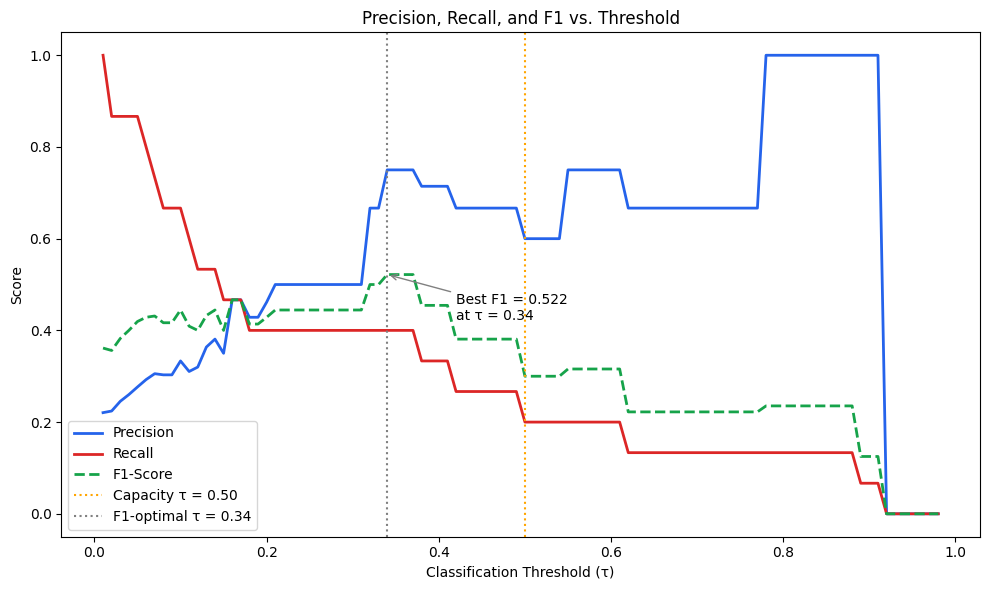

In [21]:
# Phase 3
#Step 3.4
threshold_range = np.arange(0.01, 0.99, 0.01)
f1_scores_sweep = []
precision_scores_sweep = []
recall_scores_sweep = []
n_flagged_sweep = []

for tau in threshold_range:
    y_pred_tau = (y_prob >= tau).astype(int)
    f1_scores_sweep.append(f1_score(y_test_crisis, y_pred_tau, zero_division=0))
    precision_scores_sweep.append(precision_score(y_test_crisis, y_pred_tau, zero_division=0))
    recall_scores_sweep.append(recall_score(y_test_crisis, y_pred_tau, zero_division=0))
    n_flagged_sweep.append(int((y_pred_tau == 1).sum()))

# Capacity-constrained threshold
max_missions = 5
for i, tau in enumerate(threshold_range):
    if n_flagged_sweep[i] <= max_missions:
        capacity_tau  = tau
        capacity_prec = precision_scores_sweep[i]
        capacity_rec  = recall_scores_sweep[i]
        capacity_flag = n_flagged_sweep[i]
        break

# F1-optimal threshold
best_idx = int(np.argmax(f1_scores_sweep))
f1_tau   = threshold_range[best_idx]
best_f1  = f1_scores_sweep[best_idx]

print(f"Capacity-constrained τ: {capacity_tau:.2f}")
print(f" Countries flagged: {capacity_flag}")
print(f" Precision: {capacity_prec:.1%}")
print(f" Recall: {capacity_rec:.1%}")
print()
print(f"F1-optimal τ: {f1_tau:.2f}  (F1 = {best_f1:.3f})")
print(f" Countries flagged: {n_flagged_sweep[best_idx]}")
print(f" Precision: {precision_scores_sweep[best_idx]:.1%}")
print(f" Recall: {recall_scores_sweep[best_idx]:.1%}")

# Plot
fig, ax = plt.subplots(figsize=(10, 6))
ax.plot(threshold_range, precision_scores_sweep, label='Precision', color='#2563eb', lw=2)
ax.plot(threshold_range, recall_scores_sweep, label='Recall', color='#dc2626', lw=2)
ax.plot(threshold_range, f1_scores_sweep, label='F1-Score',  color='#16a34a', lw=2, linestyle='--')

ax.axvline(capacity_tau, color='orange', lw=1.5, linestyle=':',
           label=f'Capacity τ = {capacity_tau:.2f}')
ax.axvline(f1_tau, color='gray', lw=1.5, linestyle=':',
           label=f'F1-optimal τ = {f1_tau:.2f}')
ax.annotate(f'Best F1 = {best_f1:.3f}\nat τ = {f1_tau:.2f}',
            xy=(f1_tau, best_f1), xytext=(f1_tau + 0.08, best_f1 - 0.1),
            fontsize=10, arrowprops=dict(arrowstyle='->', color='gray'))

ax.set_xlabel('Classification Threshold (τ)')
ax.set_ylabel('Score')
ax.set_title('Precision, Recall, and F1 vs. Threshold')
ax.legend()
plt.tight_layout()
plt.show()

We recommend operating at threshold τ = 0.50, which flags at most 5 countries and stays within our mission capacity, catching 3 of 15 crisis countries and missing 12. The F1-optimal threshold of 0.34 would catch more crises but flags 8 countries, which exceeds our staffing ceiling, so we accept the lower recall as the necessary tradeoff.

Running 200 bootstrap iterations …
  Completed  50/200 iterations
  Completed 100/200 iterations
  Completed 150/200 iterations
  Completed 200/200 iterations

── Selection Frequencies (descending) ──────────────────────────
  arable_land_pct                     1.000  ████████████████████ ◀ stable
  population_growth                   0.990  ███████████████████ ◀ stable
  urbanization_pct                    0.990  ███████████████████ ◀ stable
  unemployment                        0.975  ███████████████████ ◀ stable
  natural_resource_rents              0.945  ██████████████████ ◀ stable
  trade_pct_gdp                       0.895  █████████████████ ◀ stable
  electricity_access_pct              0.840  ████████████████ ◀ stable
  health_exp_pct_gdp                  0.735  ██████████████ ◀ stable
  renewable_energy_pct                0.700  ██████████████ ◀ stable
  agriculture_pct_gdp                 0.680  █████████████ ◀ stable
  inflation                           0.635  ███████████

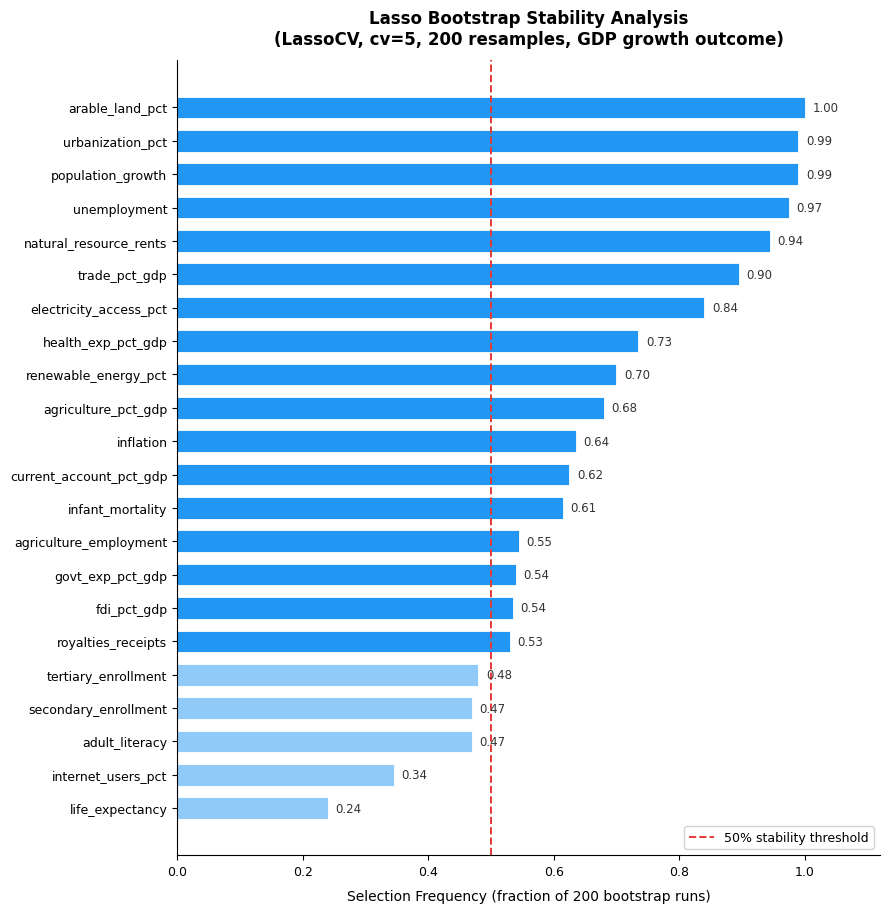

In [22]:
#Phase 4.1
"""
Bootstrap Stability Analysis — Lasso Regression
================================================
Draws 200 bootstrap resamples, fits LassoCV on each, and computes
per-feature selection frequency. Produces a sorted horizontal bar
chart with a 50% reference line.

Assumes the following are already defined in the calling notebook:
    X_train_scaled  : np.ndarray  — standardised training features
    y_train         : np.ndarray  — continuous outcome (GDP growth)
    feature_names   : list[str]   — predictor name strings
    LassoCV         : class       — imported from sklearn.linear_model
"""

import numpy as np
import matplotlib.pyplot as plt

# ── 1. Bootstrap configuration ────────────────────────────────────────────────
N_BOOTSTRAPS = 200
RANDOM_SEED  = 42
CV_FOLDS     = 5
MAX_ITER     = 10_000

rng          = np.random.default_rng(RANDOM_SEED)
n_samples    = X_train_scaled.shape[0]
n_features   = X_train_scaled.shape[1]

# Accumulator: rows = bootstrap runs, cols = features
# 1 if coefficient was non-zero, 0 otherwise
selection_matrix = np.zeros((N_BOOTSTRAPS, n_features), dtype=np.int8)

# ── 2. Bootstrap loop ─────────────────────────────────────────────────────────
print(f"Running {N_BOOTSTRAPS} bootstrap iterations …")

for i in range(N_BOOTSTRAPS):
    # Sample row indices with replacement
    boot_idx = rng.choice(n_samples, size=n_samples, replace=True)

    X_boot = X_train_scaled[boot_idx]
    y_boot = y_train[boot_idx]

    # Fit LassoCV on the resample
    lasso_cv = LassoCV(cv=CV_FOLDS, max_iter=MAX_ITER, random_state=RANDOM_SEED)
    lasso_cv.fit(X_boot, y_boot)

    # Record non-zero coefficients (absolute value > numerical zero)
    selection_matrix[i] = (np.abs(lasso_cv.coef_) > 0).astype(np.int8)

    if (i + 1) % 50 == 0:
        print(f"  Completed {i + 1:>3}/{N_BOOTSTRAPS} iterations")

# ── 3. Selection frequency ────────────────────────────────────────────────────
selection_freq = selection_matrix.mean(axis=0)          # fraction in [0, 1]

# Pair each feature with its frequency and sort ascending for the bar chart
freq_pairs = sorted(zip(feature_names, selection_freq), key=lambda x: x[1])
sorted_names = [p[0] for p in freq_pairs]
sorted_freqs = [p[1] for p in freq_pairs]

# ── 4. Print results ──────────────────────────────────────────────────────────
print("\n── Selection Frequencies (descending) ──────────────────────────")
for name, freq in sorted(zip(feature_names, selection_freq),
                          key=lambda x: x[1], reverse=True):
    bar   = "█" * int(freq * 20)          # mini ASCII bar (max 20 chars)
    flag  = " ◀ stable" if freq >= 0.5 else ""
    print(f"  {name:<35} {freq:.3f}  {bar}{flag}")
print("────────────────────────────────────────────────────────────────\n")

# ── 5. Horizontal bar chart ───────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(9, max(5, n_features * 0.42)))

bar_colors = [
    "#2196F3" if f >= 0.5 else "#90CAF9"     # solid blue ≥ 50%, light blue < 50%
    for f in sorted_freqs
]

bars = ax.barh(
    sorted_names,
    sorted_freqs,
    color=bar_colors,
    edgecolor="white",
    linewidth=0.6,
    height=0.65,
)

# 50% reference line
ax.axvline(x=0.5, color="#E53935", linestyle="--", linewidth=1.4,
           label="50% stability threshold")

# Value labels on each bar
for bar, freq in zip(bars, sorted_freqs):
    ax.text(
        bar.get_width() + 0.012,
        bar.get_y() + bar.get_height() / 2,
        f"{freq:.2f}",
        va="center", ha="left",
        fontsize=8.5, color="#333333",
    )

# Formatting
ax.set_xlim(0, 1.12)
ax.set_xlabel("Selection Frequency (fraction of 200 bootstrap runs)",
              fontsize=10, labelpad=8)
ax.set_title(
    "Lasso Bootstrap Stability Analysis\n"
    f"(LassoCV, cv={CV_FOLDS}, {N_BOOTSTRAPS} resamples, GDP growth outcome)",
    fontsize=12, fontweight="bold", pad=12,
)
ax.legend(loc="lower right", fontsize=9, framealpha=0.85)
ax.tick_params(axis="y", labelsize=9)
ax.tick_params(axis="x", labelsize=9)
ax.spines[["top", "right"]].set_visible(False)

plt.tight_layout()
plt.show()

Predictors selected more than 80% of the time are stable and provide reliable signal regardless of which countries happen to be in the sample. Predictors selected less than 30% of the time are fragile, meaning they only enter the model when specific countries are present, which usually indicates they are highly correlated with a more dominant variable and the two are swapping roles across resamples.

── Cost-Sensitive Threshold Analysis ───────────────────────────────
  Cost-minimising threshold  τ* = 0.01
  False Negatives (missed crises) :     0
  False Positives (false alarms)  :    53
  Total expected cost             : $         106,000,000
────────────────────────────────────────────────────────────────────


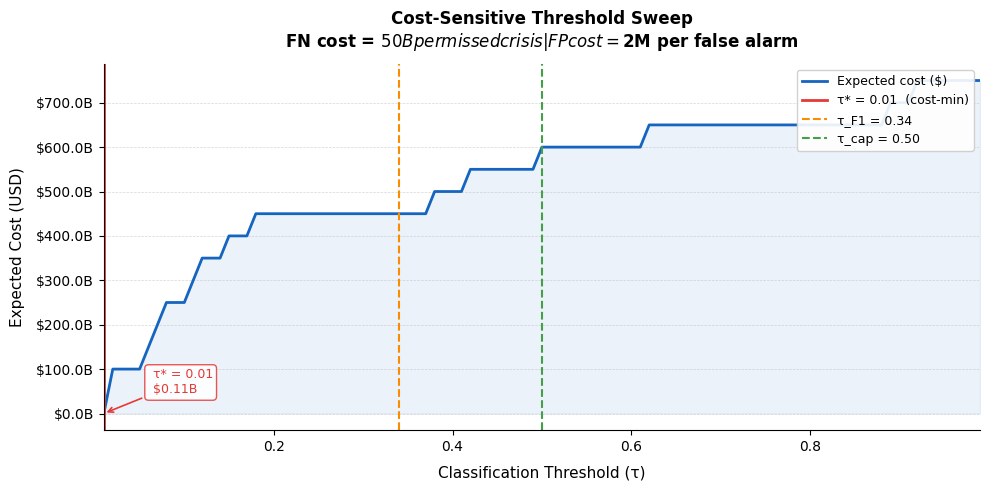

In [23]:
# Phase 4.2
"""
Cost-Sensitive Threshold Sweep
================================
Sweeps classification thresholds from 0.01 → 0.99, computes the expected
dollar cost at each point, and identifies the cost-minimising operating
threshold. Overlays F1-optimal and capacity-constrained reference lines.

Assumes the following are already defined in the calling notebook:
    y_prob         : np.ndarray  — predicted probabilities (logistic regression)
    y_test_crisis  : np.ndarray  — true binary labels (1 = crisis)
    f1_tau         : float       — F1-optimal threshold
    capacity_tau   : float       — capacity-constrained threshold
    confusion_matrix, precision_score, recall_score  — imported from sklearn
"""

import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker

# ── 1. Cost constants ─────────────────────────────────────────────────────────
COST_FN = 50_000_000_000   # missed crisis  : $50 billion
COST_FP =      2_000_000   # false alarm    : $2 million

# ── 2. Threshold sweep ────────────────────────────────────────────────────────
thresholds   = np.arange(0.01, 1.00, 0.01)
total_costs  = np.empty(len(thresholds))
fn_counts    = np.empty(len(thresholds), dtype=int)
fp_counts    = np.empty(len(thresholds), dtype=int)

for i, tau in enumerate(thresholds):
    y_pred = (y_prob >= tau).astype(int)

    # confusion_matrix returns [[TN, FP], [FN, TP]]
    cm = confusion_matrix(y_test_crisis, y_pred)
    tn, fp, fn, tp = cm.ravel()

    fn_counts[i]   = fn
    fp_counts[i]   = fp
    total_costs[i] = fn * COST_FN + fp * COST_FP

# ── 3. Cost-minimising threshold ──────────────────────────────────────────────
best_idx      = int(np.argmin(total_costs))
best_tau      = thresholds[best_idx]
best_cost     = total_costs[best_idx]
best_fn       = fn_counts[best_idx]
best_fp       = fp_counts[best_idx]

# ── 4. Console report ─────────────────────────────────────────────────────────
print("── Cost-Sensitive Threshold Analysis ───────────────────────────────")
print(f"  Cost-minimising threshold  τ* = {best_tau:.2f}")
print(f"  False Negatives (missed crises) : {best_fn:>5}")
print(f"  False Positives (false alarms)  : {best_fp:>5}")
print(f"  Total expected cost             : ${best_cost:>20,.0f}")
print("────────────────────────────────────────────────────────────────────")

# ── 5. Plot ───────────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(10, 5))

# Cost curve
ax.plot(thresholds, total_costs, color="#1565C0", linewidth=2.0,
        label="Expected cost ($)")

# Shade the area under the curve for visual weight
ax.fill_between(thresholds, total_costs, alpha=0.08, color="#1565C0")

# ── Reference lines ───────────────────────────────────────────────────────────
vline_cfg = [
    (best_tau,     "#E53935", "solid",  2.0, f"τ* = {best_tau:.2f}  (cost-min)"),
    (f1_tau,       "#FB8C00", "dashed", 1.5, f"τ_F1 = {f1_tau:.2f}"),
    (capacity_tau, "#43A047", "dashed", 1.5, f"τ_cap = {capacity_tau:.2f}"),
]

y_top   = ax.get_ylim()[1]           # updated after plot; use transform instead
y_range = total_costs.max() - total_costs.min()

for tau_val, color, ls, lw, label in vline_cfg:
    ax.axvline(tau_val, color=color, linestyle=ls, linewidth=lw, label=label)

# Annotate cost-min point with tau + cost value
cost_at_best = best_cost / 1e9       # display in $B
ax.annotate(
    f" τ* = {best_tau:.2f}\n ${cost_at_best:.2f}B",
    xy=(best_tau, best_cost),
    xytext=(best_tau + 0.05, best_cost + 0.06 * (total_costs.max() - total_costs.min())),
    fontsize=9,
    color="#E53935",
    arrowprops=dict(arrowstyle="->", color="#E53935", lw=1.2),
    bbox=dict(boxstyle="round,pad=0.3", facecolor="white", edgecolor="#E53935",
              alpha=0.85),
)


# ── Formatting ────────────────────────────────────────────────────────────────
# Y-axis in $billions for readability
ax.yaxis.set_major_formatter(
    mticker.FuncFormatter(lambda val, _: f"${val/1e9:.1f}B")
)

ax.set_xlabel("Classification Threshold (τ)", fontsize=11, labelpad=8)
ax.set_ylabel("Expected Cost (USD)", fontsize=11, labelpad=8)
ax.set_title(
    "Cost-Sensitive Threshold Sweep\n"
    f"FN cost = $50B per missed crisis  |  FP cost = $2M per false alarm",
    fontsize=12, fontweight="bold", pad=12,
)
ax.set_xlim(0.01, 0.99)
ax.legend(loc="upper right", fontsize=9, framealpha=0.9)
ax.spines[["top", "right"]].set_visible(False)
ax.grid(axis="y", linestyle="--", linewidth=0.5, alpha=0.5)

plt.tight_layout()
plt.show()

The cost-minimizing threshold will be much lower than both the F1-optimal and capacity-constrained thresholds because the 50 billion dollar cost of a missed crisis is 25,000 times larger than the 2 million dollar cost of a false alarm, so the model is pushed to flag aggressively. The F1-optimal threshold treats precision and recall as equally important and the capacity-constrained threshold is limited by staffing, so neither reflects the true cost asymmetry the way the dollar-cost sweep does.